# Data Model and IFU Indexing

This notebook describes the HETDEX PDR1 data model. All PDR1 datacubes are listed in the ifu-index file which is described in this notebook. It is recommend to first query the IFU index to determine which cubes you want to work with (see Notebook 06 for coordinate query examples). If you are a fan of DS9 regions, you can see how to create those from the IFU index at the end of this notebook.

In [1]:
import os
import os.path as op
import numpy as np

import subprocess

from astropy.table import Table
from astropy.coordinates import SkyCoord

## Data Model Overview

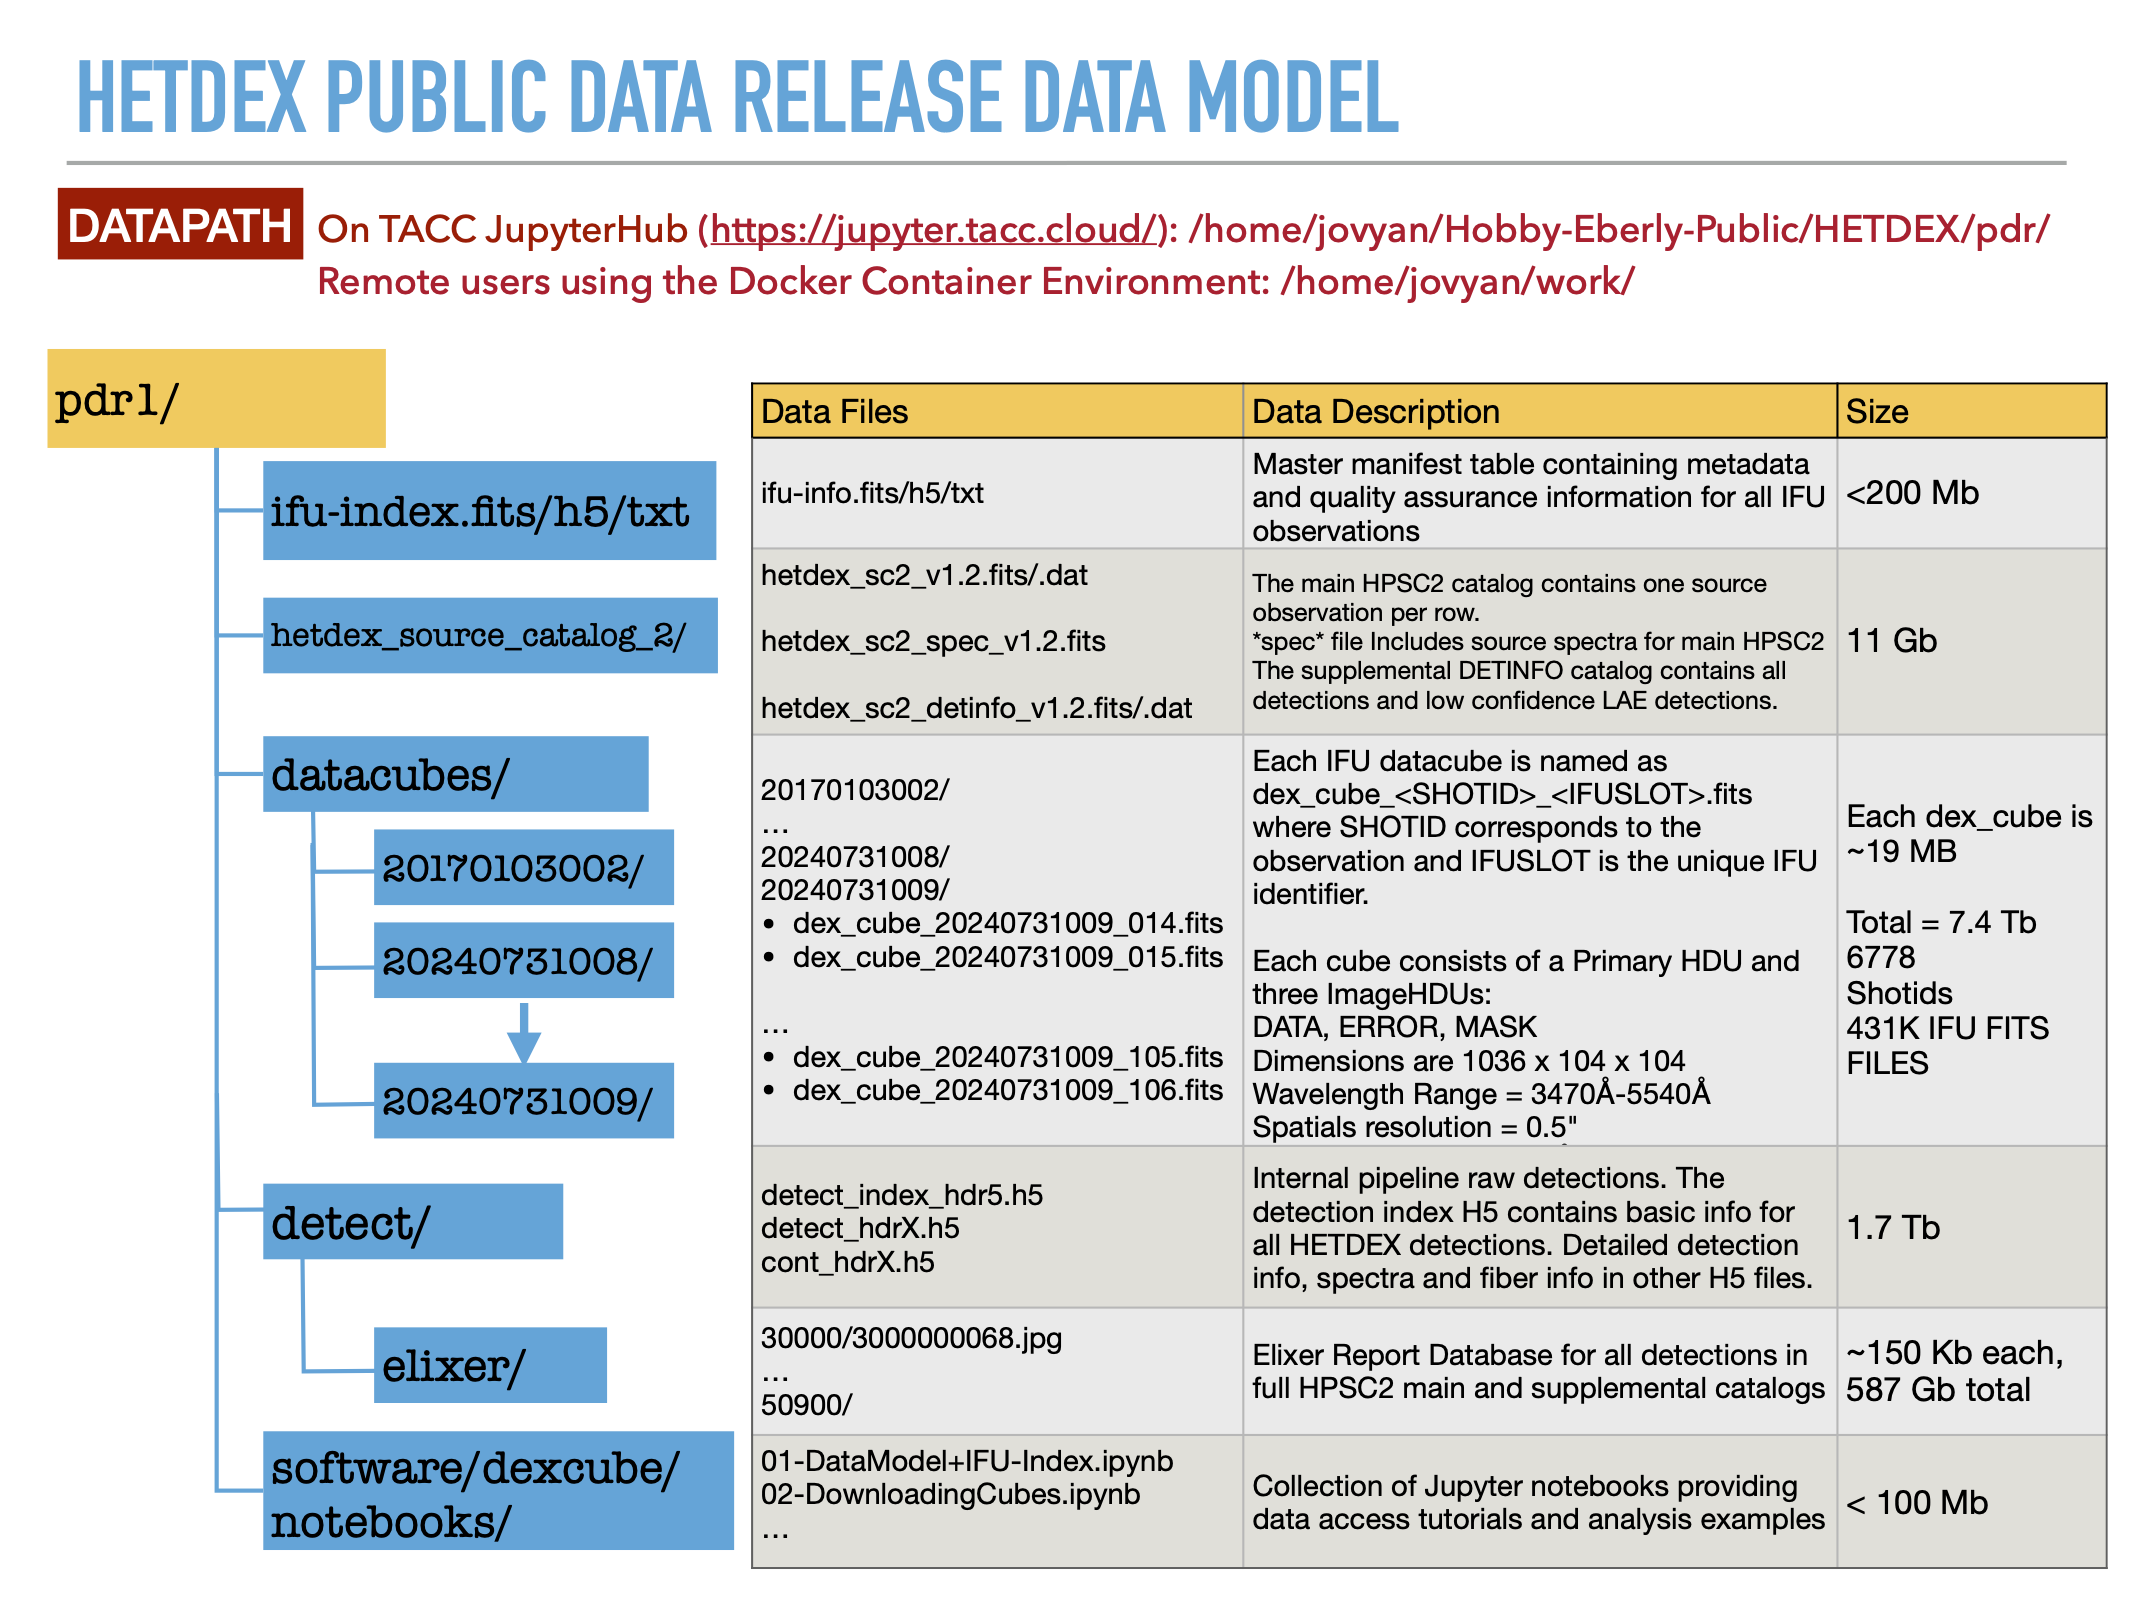

In [2]:
from IPython.display import Image, display

display(Image('https://raw.githubusercontent.com/HETDEX/dexcube/main/datamodel.png'))

## If Operating Remotely Download the ifu-index.fits file

In [3]:
# Check if this is running within the HETDEX JupyterHub
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
if op.exists( pdr_dir):
    flag_remote = False
else:
    flag_remote = True
    # set directory to store pdr1 downloads. This is recommend if working in a docker container, otherwise edit path to your liking
    pdr_dir = '/home/jovyan/work/pdr1'

In [4]:
if flag_remote:

    url = "http://web.corral.tacc.utexas.edu/hetdex/HETDEX/pdr/pdr1/ifu-index.fits"

    # ensure directory exists
    os.makedirs(pdr_dir, exist_ok=True)

    output_file = op.join(pdr_dir, "ifu-index.fits")

    if not op.exists(output_file):
        subprocess.run([
            "wget",
            "--quiet",
            "-O", output_file,
            url
        ])
        print("Downloaded:", output_file)
    else:
        print("File already exists:", output_file)

## IFU Info

In [5]:
ifu_data = Table.read(op.join( pdr_dir, 'ifu-index.fits'))

| Column Name     | Description                                               | Data Type   | Units   |
|----------------|-----------------------------------------------------------|-------------|---------|
| shotid          | Shot ID integer representing a shot: DATEOBS              | int64       | —       |
| ifuslot         | IFU slot number (e.g., 046, 063, etc.)                    | str         | —       |
| ra_cen          | Right Ascension of IFU center (ICRS)                      | float32     | deg     |
| dec_cen         | Declination of IFU center (ICRS)                          | float32     | deg     |
| flag            | Fraction of the IFU flagged overall                       | float32     | —       |
| flag_badamp     | Fraction of IFU flagged for bad amplifier(s)              | float32     | —       |
| flag_badfib     | Fraction of IFU flagged for bad fiber(s)                  | float32     | —       |
| flag_meteor     | Fraction of IFU flagged for meteor trail contamination    | float32     | —       |
| flag_satellite  | Fraction of IFU flagged for satellite trail contamination | float32     | —       |
| flag_shot       | Fraction of IFU flagged at the shot level                 | float32     | —       |
| flag_throughput | Fraction of IFU flagged for low throughput                | float32     | —       |
| field           | Field identifier (e.g., 'dex-spring')                     | str         | —       |
| objid           | Object ID (string identifier)                             | str         | —       |
| date            | Date of the observation                                   | int32       | —       |
| obsid           | Observation index                                         | int32       | —       |
| ra_shot         | RA of shot center                                         | float64     | deg     |
| dec_shot        | Dec of shot center                                        | float64     | deg     |
| pa              | Parallactic angle                                         | float64     | deg     |
| n_ifu           | Number of active IFUs in the shot                         | int32       | —       |
| fwhm_virus      | Seeing (FWHM) from VIRUS                                  | float32     | arcsec  |
| fwhm_virus_err  | Error in seeing measurement                               | float32     | arcsec  |
| response_4540   | Normalized system throughput at 4540 Å                    | float32     | —       |
| ambtemp         | Ambient temperature                                       | float32     | °C      |
| datevobs        | Observation date string                                   | str         | —       |
| dewpoint        | Dew point                                                 | float32     | °C      |
| exptime         | Exposure time                                             | float32     | s       |
| humidity        | Relative humidity                                         | float32     | %       |
| mjd             | Modified Julian Date                                      | float32     | d       |
| nstars_fit_fwhm | Number of stars used for seeing estimate                  | int32       | —       |
| obsind          | Observation index (unused)                                | int32       | —       |
| pressure        | Barometric pressure                                       | float32     | Torr    |
| structaz        | Telescope azimuth                                         | float32     | deg     |
| time            | Start time of exposure                                    | str         | UTC     |
| trajcdec        | TRAJDEC from telescope header                             | float32     | deg     |
| trajcpa         | TRAJPA (parallactic angle)                                | float32     | deg     |
| trajcra         | TRAJRA from telescope header                              | float32     | deg     |


## Writing DS9 Region Files

The following cells demonstrate how to write DS9 region files for HETDEX IFU footprints. 
Each IFU is represented as a 51″ × 51″ box oriented by the celestial position angle derived
from the HET tracker rotation stored in the `pa` column of `ifu-index.fits`:

$$\theta = 360° - (90° + \mathrm{pa} + 1.55°)$$

The `write_ifu_region_file()` function accepts any subset of the `ifu-index` table, so you
can filter by field, shot quality, flag, or sky position before writing. Region files are
written in FK5 (J2000) coordinates and can be loaded directly into DS9 or any other
region-file-aware tool (e.g. `regions` Python package, Aladin).

The example below selects all IFUs within 45 arcminutes of M101 (NGC 5457, the Pinwheel
Galaxy) as a simple demonstration of a coordinate-based spatial query.

In [6]:
def write_ifu_region_file(ifu_table, outfile='ifu_footprints.reg', color='green'):
    """
    Write DS9 region file for IFU footprints from ifu-index table.
    Each IFU is a 51"x51" box rotated by the celestial PA.
    PA convention: theta = 360 - (90 + pa + 1.55)
    """
    IFU_SIZE = 51.0  # arcsec

    with open(outfile, 'w') as f:
        f.write('# DS9 region file\n')
        f.write('global color={} width=1 font="helvetica 10 normal" select=1\n'.format(color))
        f.write('fk5\n')
        for row in ifu_table:
            theta = 360.0 - (90.0 + row['pa'] + 1.55)
            f.write(
                'box({:.6f},{:.6f},{:.2f}",{:.2f}",{:.2f})\n'.format(
                    row['ra_cen'], row['dec_cen'],
                    IFU_SIZE, IFU_SIZE, theta
                )
            )
    print(f'Wrote {len(ifu_table)} regions to {outfile}')

In [7]:
# Example: write all good IFUs
good = ifu_data[ifu_data['flag'] > 0.5]
# uncomment to run
#write_ifu_region_file(good, outfile='ifu_footprints_good.reg', color='green')

# Or filter by field
spring = ifu_data[ifu_data['field'] == 'dex-spring']
# uncomment to run
# write_ifu_region_file(spring, outfile='ifu_footprints_spring.reg', color='cyan')

## Plot Up IFU footprints on M101

In [8]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# M101 center
m101 = SkyCoord(ra=210.802*u.deg, dec=54.349*u.deg, frame='icrs')

# Match against ifu-index
ifu_coords = SkyCoord(ra=ifu_data['ra_cen'], dec=ifu_data['dec_cen'], unit='deg', frame='icrs')
sep = m101.separation(ifu_coords)

# Filter within 15 arcmin
m101_ifus = ifu_data[sep < 15*u.arcmin]
print(f'Found {len(m101_ifus)} IFUs within 45 arcmin of M101')

write_ifu_region_file(m101_ifus, outfile='ifu_m101_15arcmin.reg', color='cyan')

Found 629 IFUs within 45 arcmin of M101
Wrote 629 regions to ifu_m101_15arcmin.reg


In [17]:
from urllib.request import urlopen
from io import BytesIO
from astropy.visualization import make_lupton_rgb
from astropy.wcs import WCS

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from astropy.io import fits
import re

# --- fetch Legacy Surveys RGB ---
fov = 0.4 * u.deg
pixscale = 5  # arcsec/pixel
npix = int(np.ceil(fov.to(u.arcsec).value / pixscale))

def fetch_legacy_fits(ra, dec, npix, pixscale, band, layer='ls-dr10'):
    url = (f'https://www.legacysurvey.org/viewer/cutout.fits'
           f'?ra={ra:.8f}&dec={dec:.8f}&layer={layer}'
           f'&pixscale={pixscale:.6f}&size={npix}&bands={band}')
    with urlopen(url) as resp:
        hdul = fits.open(BytesIO(resp.read()))
    for ext in [0, 1]:
        if hdul[ext].data is not None and hdul[ext].data.ndim == 2:
            return hdul[ext].data.astype(float), WCS(hdul[ext].header)

g, legacy_wcs = fetch_legacy_fits(m101.ra.deg, m101.dec.deg, npix, pixscale, 'g')
r, _          = fetch_legacy_fits(m101.ra.deg, m101.dec.deg, npix, pixscale, 'r')
z, _          = fetch_legacy_fits(m101.ra.deg, m101.dec.deg, npix, pixscale, 'z')
for arr in (g, r, z):
    arr[~np.isfinite(arr)] = 0.0
    
rgb = make_lupton_rgb(z, r, g, stretch=0.10, Q=2.5)

# --- box corner helper ---
def box_corners(ra, dec, width_arcsec, height_arcsec, pa_deg):
    w = width_arcsec / 3600 / 2
    h = height_arcsec / 3600 / 2
    cos_dec = np.cos(np.radians(dec))
    pa = np.radians(pa_deg)
    cos_pa, sin_pa = np.cos(pa), np.sin(pa)
    corners_local = np.array([[-w,-h],[w,-h],[w,h],[-w,h]])
    corners = []
    for dx, dy in corners_local:
        dra_rot  = ( dx*cos_pa - dy*sin_pa) / cos_dec
        ddec_rot = ( dx*sin_pa + dy*cos_pa)
        corners.append((ra + dra_rot, dec + ddec_rot))
    return np.array(corners)


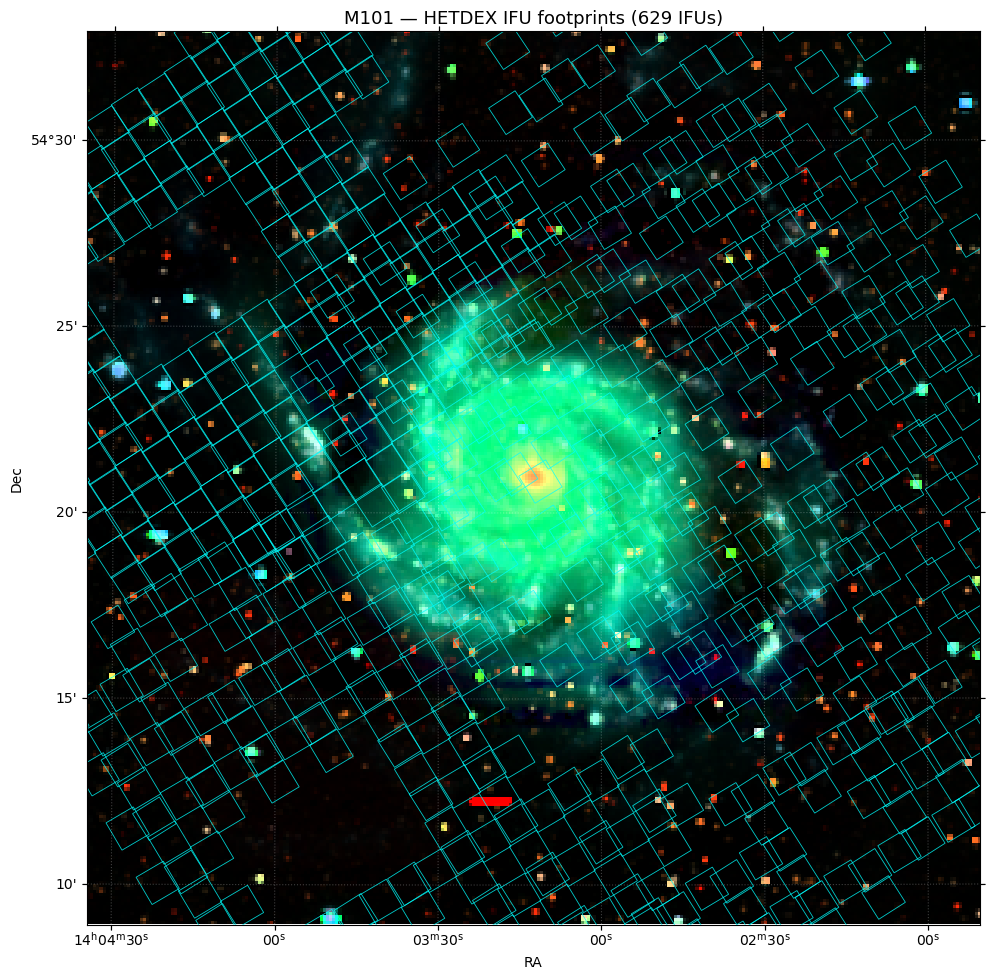

In [18]:
# --- plot with WCS projection ---
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=legacy_wcs)

ax.imshow(rgb, origin='lower')

with open('ifu_m101_15arcmin.reg') as f:
    for line in f:
        m = re.match(r'box\(([^)]+)\)', line)
        if m:
            vals = m.group(1).split(',')
            ra  = float(vals[0])
            dec = float(vals[1])
            w   = float(vals[2].replace('"',''))
            h   = float(vals[3].replace('"',''))
            pa  = float(vals[4])
            sky_corners = box_corners(ra, dec, w, h, pa)
            pix_corners = np.array([legacy_wcs.world_to_pixel(
                          SkyCoord(rc*u.deg, dc*u.deg)) for rc, dc in sky_corners])
            ax.add_patch(Polygon(pix_corners, closed=True, fill=False,
                                 edgecolor='cyan', lw=0.6, alpha=0.8))

# zoom to 45 arcmin
x_cen, y_cen = legacy_wcs.world_to_pixel(m101)

ax.coords[0].set_axislabel('RA')
ax.coords[1].set_axislabel('Dec')
ax.coords.grid(color='white', alpha=0.25, ls=':')
ax.set_title(f'M101 — HETDEX IFU footprints ({len(m101_ifus)} IFUs)', fontsize=13)
plt.tight_layout()
plt.show()